In [14]:
import pandas as pd


df = pd.read_csv("hotel_bookings.csv")

# turning it to a binary (0=not reserved by a company)
df['has_company'] = df['company'].notna().astype(int)

# categorize agent
df['agent'] = df['agent'].fillna(-1).astype(int).astype(str)

# fill null values (4 missing so its fine)
df['children'] = df['children'].fillna(0)

# fill null values with unknown
df['country'] = df['country'].fillna("Unknown")

X = df.drop(['is_canceled', 'reservation_status', 'reservation_status_date', 'company'], axis=1)
y = df['is_canceled']


In [15]:
# Split data into 80/20 ratio
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [16]:
# Preprocess and Model's pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder
from imblearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier


# list of object(d_type)
need_encode = [col for col in X.select_dtypes(include='object')]
print(need_encode)

# encode object (object -> int)
preprocess = ColumnTransformer(
    transformers = [
        ('Encode_Feat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), need_encode)
    ],
    remainder='passthrough'
)

pipeline = Pipeline([
    ('preprocess', preprocess),
    ('model', RandomForestClassifier(oob_score=True, random_state=42))
])


['hotel', 'arrival_date_month', 'meal', 'country', 'market_segment', 'distribution_channel', 'reserved_room_type', 'assigned_room_type', 'deposit_type', 'agent', 'customer_type']


C:\Users\User\AppData\Local\Temp\ipykernel_17740\2370096141.py:9: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  need_encode = [col for col in X.select_dtypes(include='object')]


In [17]:
# Fine-tune model
from sklearn.model_selection import GridSearchCV

param_grid = {
    "model__n_estimators" : [100, 300, 500],
    "model__class_weight" : ['balanced', 'balanced_subsample'],
    "model__max_depth" : [None, 15, 25]
}

grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring='recall',
    n_jobs=-1,
    verbose=1
)

In [18]:
# Train model
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 18 candidates, totalling 90 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__class_weight': ['balanced', 'balanced_subsample'], 'model__max_depth': [None, 15, ...], 'model__n_estimators': [100, 300, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'recall'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sph

In [23]:
predictions = grid_search.predict(X_test)
print(predictions)

# Best Hyperparameter Found
print(grid_search.best_params_)

# Best Features Found
best_estimator = grid_search.best_estimator_
model = best_estimator.named_steps['model']
print(model.feature_importances_)

[0 0 1 ... 0 0 1]
{'model__class_weight': 'balanced', 'model__max_depth': 25, 'model__n_estimators': 500}
[0.01111594 0.025117   0.01134371 0.12219182 0.05314828 0.01204839
 0.01500407 0.0252044  0.10784583 0.06682146 0.02699943 0.11810782
 0.0270234  0.04343746 0.04302908 0.0184135  0.02873279 0.01131459
 0.0055832  0.0007984  0.00245031 0.02983475 0.00557153 0.0235494
 0.00178079 0.06475221 0.03226788 0.06409365 0.00241891]


In [20]:
# Classification and Confusion Matrix
from sklearn.metrics import classification_report, confusion_matrix


print(classification_report(y_test, predictions))
print(f"\n\nConfusion Matrix\n{confusion_matrix(y_test, predictions)}")

              precision    recall  f1-score   support

           0       0.92      0.91      0.92     15033
           1       0.85      0.86      0.86      8845

    accuracy                           0.89     23878
   macro avg       0.89      0.89      0.89     23878
weighted avg       0.89      0.89      0.89     23878



Confusion Matrix
[[13704  1329]
 [ 1216  7629]]


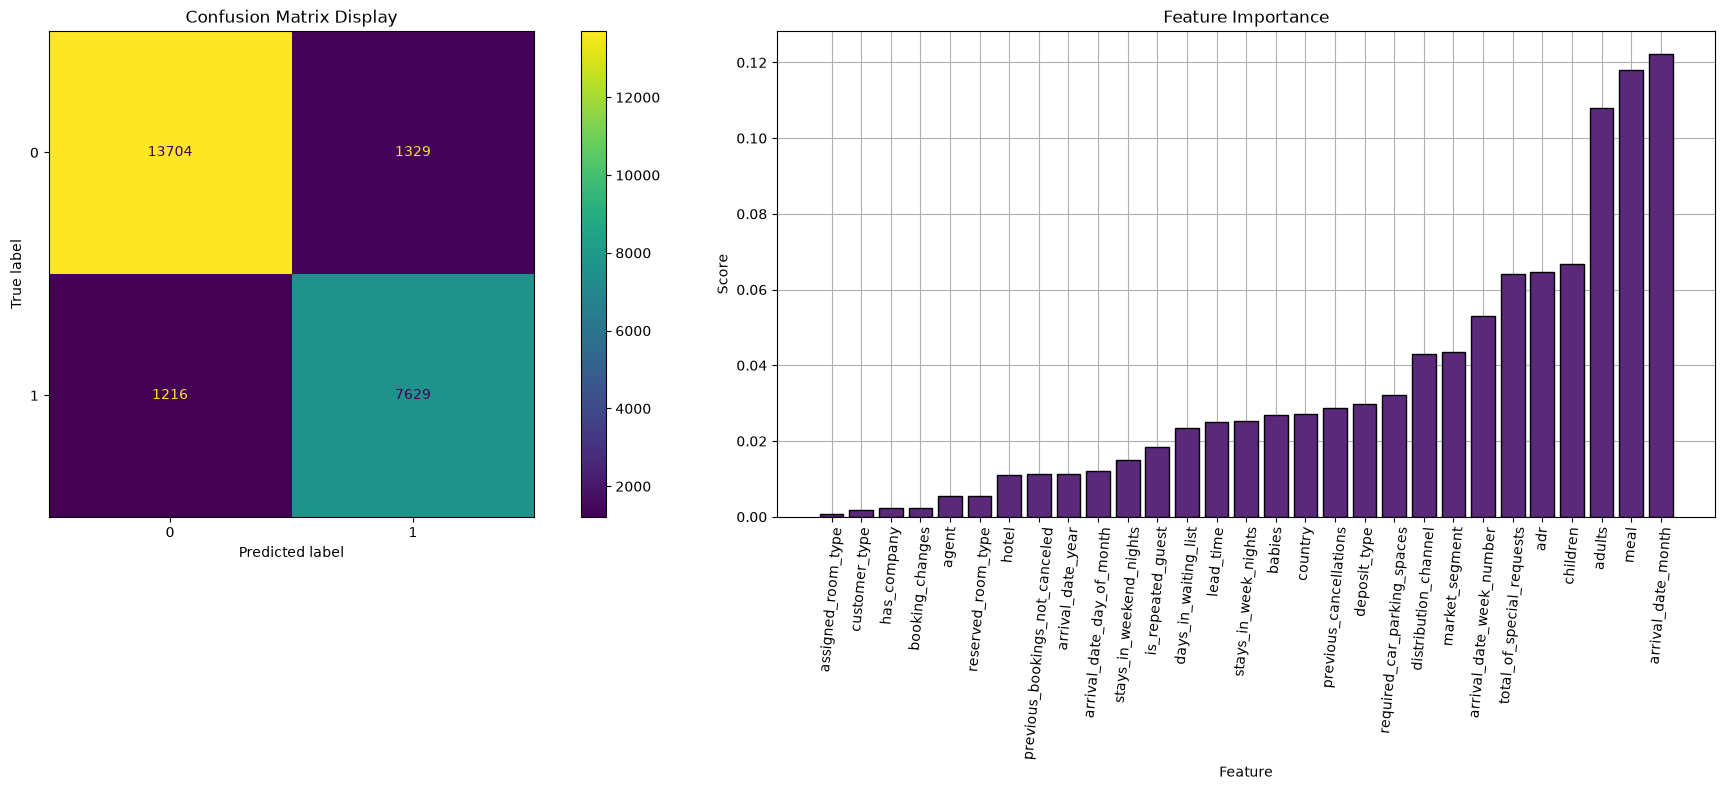

In [38]:
# VISUALIZATIONS
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Confusion Matrix Display
ConfusionMatrixDisplay.from_predictions(y_test, predictions, ax=axes[0])
axes[0].set_title("Confusion Matrix Display")

# Feature Importance Display
importance = pd.Series(
    model.feature_importances_,
    index=X.columns
).sort_values()

axes[1].bar(importance.index, importance.values, color="#5B2979", edgecolor="#000000")
axes[1].set_title("Feature Importance")
axes[1].set_xlabel("Feature")
axes[1].set_ylabel("Score")
axes[1].grid(True)
axes[1].set_axisbelow(True)
axes[1].tick_params(axis='x', rotation=85)

plt.tight_layout()

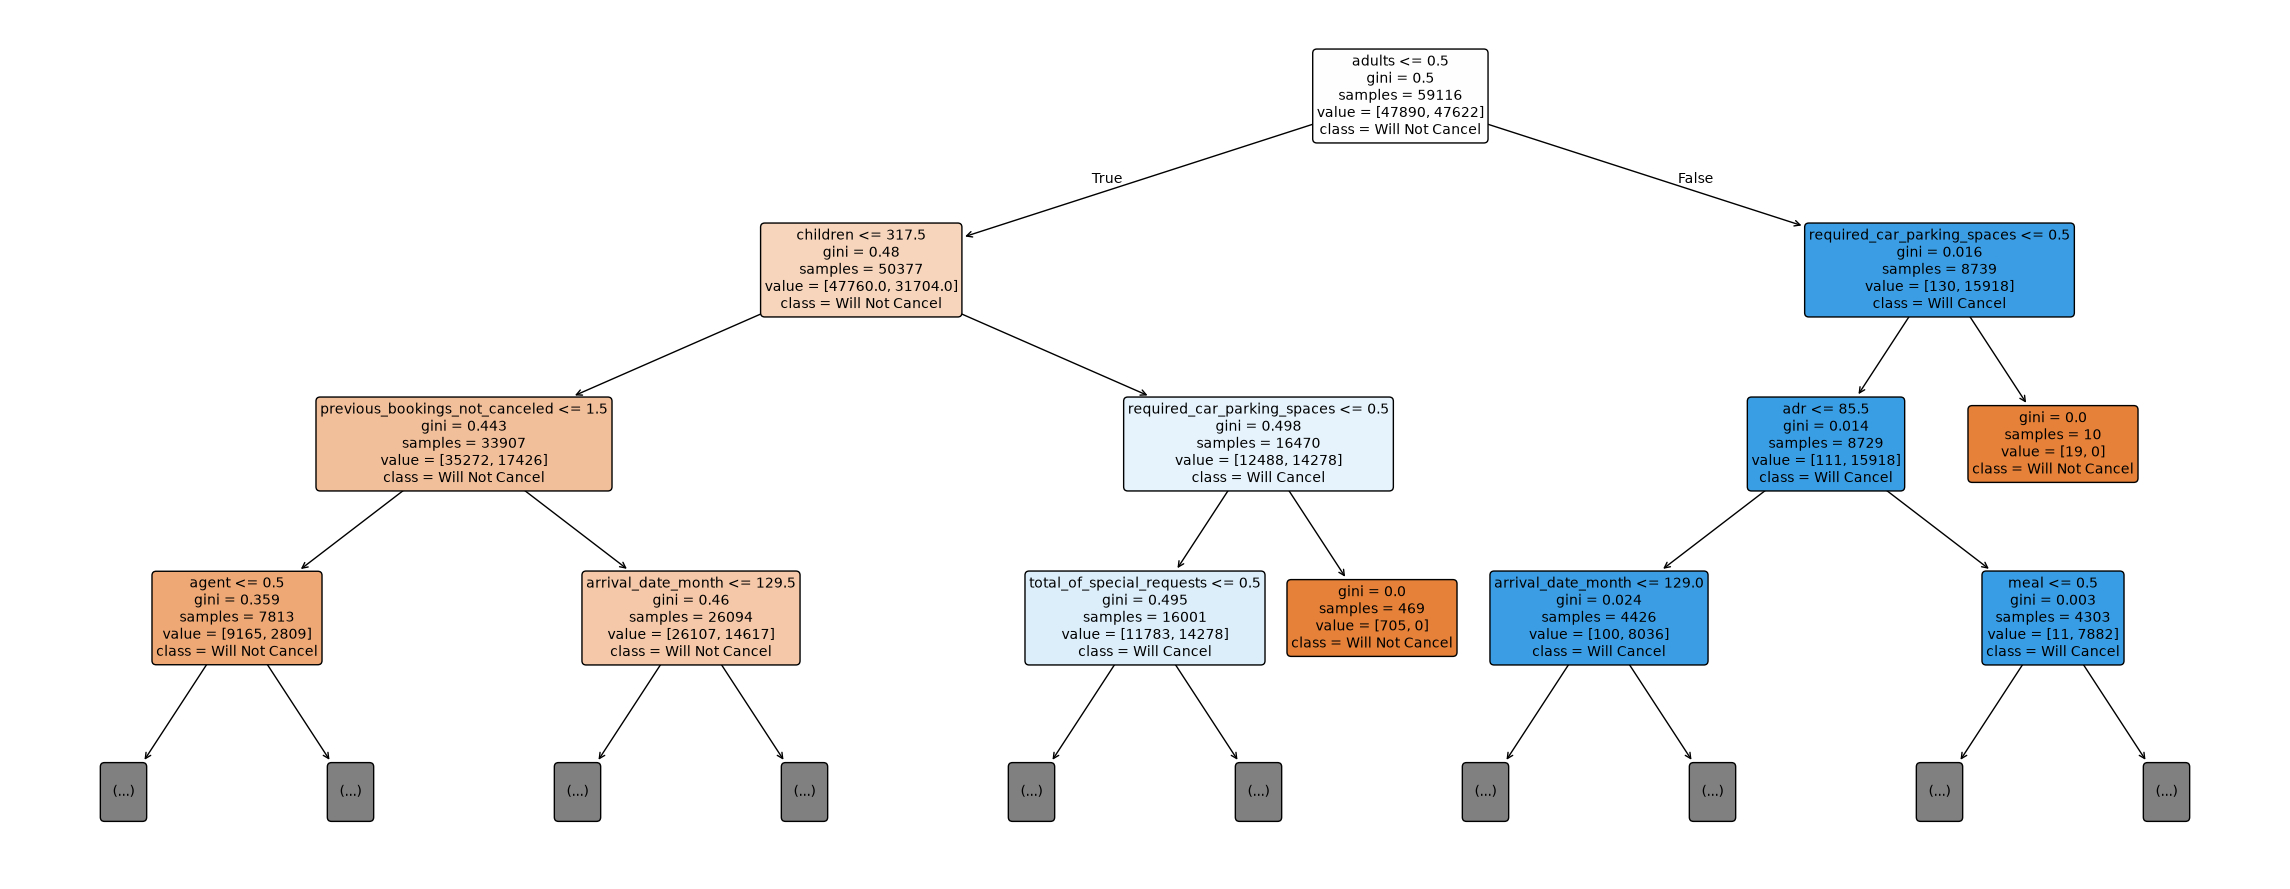

In [37]:
# Plot first tree
from sklearn.tree import plot_tree

fig, ax = plt.subplots(figsize=(23, 9))

plot_tree(
    model.estimators_[0],
    max_depth = 3,
    feature_names = X.columns,
    class_names=['Will Not Cancel', 'Will Cancel'],
    filled=True,
    rounded=True,
    fontsize=10
)

plt.tight_layout()